# Assignment: Detection of Pool Balls & POV Warp for Table Top View

**Work assembled by:**
- Alejandro Gonçalves (202205564)
- Francisca Mihalache (202206022)
- João Sousa ()
- Rafael Pacheco ()

**Year:** 2025/2026


## Table of Contents

1. [Introduction](#1-introduction)
2. [Libraries & Frameworks](#2-libraries--frameworks)
    - 2.1. [Global Variables](#21-global-variables)
3. [Loading Images](#3-loading-images)
4. [Creating Cloth Mask](#4-creating-cloth-mask)
5. [Circle Detection](#5-circle-detection)
    - 5.1. [Test ball detection on the sample image](#51-test-ball-detection-on-the-sample-image)
    - 5.2. [Debug Maps and Image Enhancement](#52-debug-maps-and-image-enhancement)
6. [Ball Identification](#6-ball-identification)
    - 6.1. [Test ball identification on the sample image](#61-test-ball-identification-on-the-sample-image)
7. [Ground Truth Generation](#7-ground-truth-generation)
8. [Bounding Box Generation](#8-bounding-box-generation)
9. [Evaluation Metrics](#9-evaluation-metrics)


### 1. Introduction
[[go back to the top]](#table-of-contents)

This notebook presents a computer vision pipeline for detecting and identifying pool (billiard) balls on a table, producing a top-down (bird's eye) perspective warp.

The main challenge consists of reliably locating the billiard table's playing surface, detecting all balls present on it, and correctly identifying each ball by its number, colour, and type (solid or striped). The approach follows three main stages:

1. **Cloth Mask** — We use colour segmentation in HSV space to isolate the green or blue playing surface, filtering out the surrounding environment.
2. **Ball Detection** — Using the Hough Circle Transform on the masked region, we detect circular objects that correspond to the billiard balls.
3. **Ball Identification** — Each detected circle is analysed using colour histograms and white-pixel ratios to assign a ball number.

All image processing is performed using **OpenCV** and **NumPy**, with **Matplotlib** used for visualisation. No additional libraries are required.


### 2. Libraries & Frameworks

[[go back to the top]](#table-of-contents)


Utils file includes every necessary function and framework for this entire notebook.

In [56]:
from utils import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### 2.1. Global Variables
[[go back to the topic]](#2-libraries--frameworks)

In [57]:
DATA_DIR = "data"

### 3. Loading Images

[[go back to the top]](#table-of-contents)


In [58]:
image_paths = sorted(glob.glob(os.path.join(DATA_DIR, "*.jpg")))
print(f"Detected {len(image_paths)} imgs")

Detected 50 imgs


### 4. Creating Cloth Mask
[[go back to the top]](#table-of-contents)

In order to optimize object detection, we decided to first mask the image to only entail the region of interest, which is the table's cloth. It's usually bright blue, but the whole dataset also has some green cloth tables, and we also wanted to prepare for possible changes. To make this a robust method, we took advantage of HSV color space to detect regions with color ranges in either blue or green, in combination with edge/corner detection filters.


In [59]:
def segment_table(img):
    # Enable hsv
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Detect blue cloth (Hue ~90-130) OR green cloth (Hue ~35-85)
    blue_mask = cv2.inRange(hsv, np.array([90, 80, 50]), np.array([130, 255, 255]))
    green_mask = cv2.inRange(hsv, np.array([35, 80, 50]), np.array([85, 255, 255]))
    mask = cv2.bitwise_or(blue_mask, green_mask)

    # Find the biggest contour -> most likely to be table
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    table_contour = max(contours, key=cv2.contourArea)

    # Approximates to 4 corners
    epsilon = 0.02 * cv2.arcLength(table_contour, True)
    approx = cv2.approxPolyDP(table_contour, epsilon, True)

    # If we don't get exactly 4 points, assumes shape 
    # closest to a 4-sided polygon
    if len(approx) == 4: corners = approx.reshape(4, 2).astype(np.float32)
    else:
        rect = cv2.minAreaRect(table_contour)
        corners = cv2.boxPoints(rect).astype(np.float32)

    # Order corners & create mask
    corners = order_corners(corners)
    clean_mask = np.zeros(img.shape[:2], dtype=np.uint8)
    cv2.fillPoly(clean_mask, [corners.astype(np.int32)], 255)

    return clean_mask, corners

Let's visualize the mask and detected corners to make sure it works.

In [60]:
sample_img = cv2.imread(random.choice(image_paths))
mask, corners = segment_table(sample_img)

# Draws corners
vis = sample_img.copy()
if corners is not None:
    for i, c in enumerate(corners):
        cv2.circle(vis, tuple(c.astype(int)), 10, (0, 255, 0), -1)
        cv2.putText(vis, str(i), tuple(c.astype(int) + [10, -10]),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

# Show corners, mask and cropped image
masked_img = cv2.bitwise_and(sample_img, sample_img, mask=mask)
show([vis, mask, masked_img], ["Corners", "Table mask", "Masked image"])

/Users/franciscamihalache/Desktop/GitHub/Computer-Vision/utils.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### 5. Circle Detection
[[go back to the top]](#table-of-contents)

Spheres have a very convenient property: no matter what angle they are photographed in, their 2D projection is always a circle.

We can take this into account and use a circle detection filter inside the mask to identify them.

First, we decided to use the simplest option, `cv2.HoughCircles`. It works by looking at edges, which are essentially sharp changes in brightness not necessarily by color. For this reason, we converted to grayscale.

For color optimization we boosted saturation and contrast and reduced shadows. The problem with this is that grayscale generalizes too much, and balls often blend with the background. In order to help with this, we also considered color distance between the balls and the cloth.


| HoughCircles parameters     |  Meaning  | Value     |
| ----------------------------|-----------|-------------------------------------------|
| minDist              | threshold of overlap between circles  |          trial and error           |
| param1              |  finds outlines high value will miss those that blend into the background  | trial and error (~40) |
| param2              |  degree of perfection of the circle|       trial and error (~30)           |
| minRadius/maxRadius   |  defines possible range of ball size    |         based on visual cues           |

In [61]:
def detect_balls(img, mask):
    masked = cv2.bitwise_and(img, img, mask=mask)
    hsv = cv2.cvtColor(masked, cv2.COLOR_BGR2HSV)
    h_chan, s_chan, v_chan = cv2.split(hsv)

    # Boost saturation and brightness
    s_chan = cv2.convertScaleAbs(s_chan, alpha=1.35, beta=10)
    v_chan = cv2.convertScaleAbs(v_chan, alpha=1.15, beta=8)

    hsv_boosted = cv2.merge([h_chan, s_chan, v_chan])
    masked_boosted = cv2.cvtColor(hsv_boosted, cv2.COLOR_HSV2BGR)

    cloth_mean = np.array(cv2.mean(masked_boosted, mask=mask)[:3])
    diff = np.sqrt(np.sum((masked_boosted.astype(np.float32) - cloth_mean) ** 2, axis=2))
    diff = np.clip(diff, 0, 255).astype(np.uint8)

    gray_raw = cv2.cvtColor(masked_boosted, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(masked_boosted, cv2.COLOR_BGR2HSV)
    h_chan, s_chan, v_chan = cv2.split(hsv)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray_clahe = clahe.apply(gray_raw)
    s_enhanced = clahe.apply(s_chan)
    

    gray = cv2.addWeighted(diff, 0.9, s_enhanced, 0.1, 0)
    gray = cv2.addWeighted(gray, 0.9, gray_raw, 0.1, 0)
    gray = cv2.GaussianBlur(gray, (3, 3), 2)

    gray_enhanced = cv2.addWeighted(diff, 0.8, s_enhanced, 0.2, 0)
    gray_enhanced = cv2.addWeighted(gray_enhanced, 0.85, gray_clahe, 0.15, 0)
    gray_enhanced = cv2.GaussianBlur(gray_enhanced, (3, 3), 2)

    h, w = img.shape[:2]
    min_r = max(8, int(h * 0.01))
    max_r = int(h * 0.025)

    # Edge map for circle validation
    edge = cv2.Canny(gray, 40, 140)
    # Pass 1: Conservative on normal image (best for clear, well-lit balls)
    circles1 = cv2.HoughCircles(
        gray, cv2.HOUGH_GRADIENT, dp=1.2, minDist=min_r * 1.7,
        param1=38, param2=29.3, minRadius=min_r, maxRadius=max_r
    )

    # Pass 2: Permissive on normal image
    circles2 = cv2.HoughCircles(
        gray, cv2.HOUGH_GRADIENT, dp=1.2, minDist=min_r * 1.7,
        param1=38, param2=26.5, minRadius=min_r, maxRadius=max_r
    )

    # Pass 3: Permissive on CLAHE enhanced image (to catch shadow balls)
    circles3 = cv2.HoughCircles(
        gray_enhanced, cv2.HOUGH_GRADIENT, dp=1.2, minDist=min_r * 1.7,
        param1=38, param2=26.5, minRadius=min_r, maxRadius=max_r
    )

    candidates = []
    if circles1 is not None:
        candidates.extend([(x, y, r, "hough") for x, y, r in np.round(circles1[0]).astype(int).tolist()])
    if circles2 is not None:
        candidates.extend([(x, y, r, "hough") for x, y, r in np.round(circles2[0]).astype(int).tolist()])
    if circles3 is not None:
        candidates.extend([(x, y, r, "hough") for x, y, r in np.round(circles3[0]).astype(int).tolist()])

        
    # detect purple blobs directly in HSV
    lower_purple = np.array([110, 40, 30], dtype=np.uint8)
    upper_purple = np.array([175, 255, 255], dtype=np.uint8)

    purple_mask = cv2.inRange(hsv, lower_purple, upper_purple)
    purple_mask = cv2.bitwise_and(purple_mask, mask)

    kernel = np.ones((3, 3), np.uint8)
    purple_mask = cv2.morphologyEx(purple_mask, cv2.MORPH_OPEN, kernel)
    purple_mask = cv2.morphologyEx(purple_mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(purple_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < np.pi * (min_r ** 2) * 0.35 or area > np.pi * (max_r ** 2) * 1.5:
            continue

        perimeter = cv2.arcLength(cnt, True)
        if perimeter == 0:
            continue

        circularity = 4 * np.pi * area / (perimeter * perimeter)
        if circularity < 0.45:
            continue

        (x, y), r = cv2.minEnclosingCircle(cnt)
        candidates.append((int(x), int(y), int(r), "purple"))

    if not candidates:
        return []

    balls = []

    for (x, y, r, source) in candidates:
        if not (0 <= y < mask.shape[0] and 0 <= x < mask.shape[1]):
            continue

        circle_mask = np.zeros_like(mask)
        if source == "purple":
            inner_mask = np.zeros_like(mask)
            cv2.circle(inner_mask, (x, y), max(2, int(r * 0.65)), 255, -1)

            purple_pixels = cv2.countNonZero(cv2.bitwise_and(purple_mask, inner_mask))
            total_pixels = cv2.countNonZero(inner_mask)

            purple_ratio = purple_pixels / max(total_pixels, 1)

            if purple_ratio < 0.45:
                continue
        
        cv2.circle(circle_mask, (x, y), r, 255, -1)

        mean_val = cv2.mean(gray, mask=circle_mask)[0]
        if mean_val < 25:
            continue

        overlap = cv2.countNonZero(cv2.bitwise_and(mask, circle_mask))
        area = cv2.countNonZero(circle_mask)
        if area == 0 or overlap / area <= 0.35:
            continue

        ring_mask = np.zeros_like(mask)
        cv2.circle(ring_mask, (x, y), r, 255, 2)

        edge_overlap = cv2.countNonZero(cv2.bitwise_and(edge, ring_mask))
        circumference = max(2 * np.pi * r, 1)

        if source != "purple" and edge_overlap / circumference < 0.20:
            continue

        balls.append((x, y, r))

    # Sort by radius descending so we process larger, more reliable circles first
    balls.sort(key=lambda b: b[2], reverse=True)

    # Remove duplicates
    deduped = []
    for x, y, r in balls:
        duplicate = False
        for x2, y2, r2 in deduped:
            center_dist = np.hypot(x - x2, y - y2)
            # If the smaller circle's center is inside the larger circle, drop it
            if center_dist < 1.0* max(r, r2):
                duplicate = True
                break
        if not duplicate:
            deduped.append((x, y, r))
    
    if len(deduped) >= 4:
        corrected_balls = []

        for i, (x, y, r) in enumerate(deduped):
            neighbors = []

            # Calculate distance to all other detected balls
            for j, (x2, y2, r2) in enumerate(deduped):
                if i == j:
                    continue
                dist = np.hypot(x - x2, y - y2)
                neighbors.append((dist, r2))

            # Sort by distance to find the closest ones
            neighbors.sort(key=lambda t: t[0])

            # Pick the closest 3 neighbors to compute local scale
            k = min(3, len(neighbors))
            local_radii = [r2 for (_, r2) in neighbors[:k]]

            if len(local_radii) > 0:
                local_median_r = np.median(local_radii)

                # If the radius is an outlier compared to its immediate neighbors,
                # correct it to the local median instead of deleting the ball.
                if r < 0.7 * local_median_r or r > 1.2 * local_median_r:
                    r = int(local_median_r)

            corrected_balls.append((x, y, r))

        deduped = corrected_balls
    return deduped


#### 5.1. Test ball detection on the sample image
[[go back to the topic]](#5-circle-detection)

Draw circles and bounding boxes around each detected ball.

In [62]:
ls = []

for path in image_paths: ls.append(path)
def build_debug_maps(img, mask):
    masked = cv2.bitwise_and(img, img, mask=mask)

    hsv = cv2.cvtColor(masked, cv2.COLOR_BGR2HSV)
    h_chan, s_chan, v_chan = cv2.split(hsv)

    s_boost = cv2.convertScaleAbs(s_chan, alpha=1.35, beta=10)
    v_boost = cv2.convertScaleAbs(v_chan, alpha=1.15, beta=8)

    hsv_boosted = cv2.merge([h_chan, s_boost, v_boost])
    masked_boosted = cv2.cvtColor(hsv_boosted, cv2.COLOR_HSV2BGR)

    cloth_mean = np.array(cv2.mean(masked_boosted, mask=mask)[:3])
    diff = np.sqrt(np.sum((masked_boosted.astype(np.float32) - cloth_mean) ** 2, axis=2))
    diff = np.clip(diff, 0, 255).astype(np.uint8)

    gray_raw = cv2.cvtColor(masked_boosted, cv2.COLOR_BGR2GRAY)
    hsv2 = cv2.cvtColor(masked_boosted, cv2.COLOR_BGR2HSV)
    _, s_chan2, _ = cv2.split(hsv2)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray_clahe = clahe.apply(gray_raw)
    s_enhanced = clahe.apply(s_chan2)

    gray = cv2.addWeighted(diff, 0.9, s_enhanced, 0.1, 0)
    gray = cv2.addWeighted(gray, 0.9, gray_raw, 0.1, 0)
    gray = cv2.GaussianBlur(gray, (3, 3), 2)

    gray_enhanced = cv2.addWeighted(diff, 0.8, s_enhanced, 0.2, 0)
    gray_enhanced = cv2.addWeighted(gray_enhanced, 0.85, gray_clahe, 0.15, 0)
    gray_enhanced = cv2.GaussianBlur(gray_enhanced, (3, 3), 2)

    lower_purple = np.array([120, 70, 40], dtype=np.uint8)
    upper_purple = np.array([165, 255, 255], dtype=np.uint8)
    purple_mask = cv2.inRange(hsv2, lower_purple, upper_purple)
    purple_mask = cv2.bitwise_and(purple_mask, mask)

    return masked, masked_boosted, diff, gray, gray_enhanced, purple_mask


for path in image_paths[:1]:
    img = cv2.imread(path)
    mask, corners = segment_table(img)
    balls = detect_balls(img, mask)

    vis = img.copy()
    for (x, y, r) in balls:
        cv2.circle(vis, (x, y), r, (0, 255, 0), 2)

    name = os.path.basename(path)
    show(
        [vis],
        [f"{name} — {len(balls)} balls"],
        figsize=(8, 6)
    )

#### 5.2. Debug Maps and Image Enhancement
[[go back to the topic]](#5-circle-detection)

In [63]:
def build_debug_maps(img, mask):
    masked = cv2.bitwise_and(img, img, mask=mask)

    hsv = cv2.cvtColor(masked, cv2.COLOR_BGR2HSV)
    h_chan, s_chan, v_chan = cv2.split(hsv)

    # Boost saturation and brightness
    s_boost = cv2.convertScaleAbs(s_chan, alpha=1.35, beta=10)
    v_boost = cv2.convertScaleAbs(v_chan, alpha=1.15, beta=8)

    hsv_boosted = cv2.merge([h_chan, s_boost, v_boost])
    masked_boosted = cv2.cvtColor(hsv_boosted, cv2.COLOR_HSV2BGR)

    cloth_mean = np.array(cv2.mean(masked_boosted, mask=mask)[:3])
    diff = np.sqrt(np.sum((masked_boosted.astype(np.float32) - cloth_mean) ** 2, axis=2))
    diff = np.clip(diff, 0, 255).astype(np.uint8)

    gray_raw = cv2.cvtColor(masked_boosted, cv2.COLOR_BGR2GRAY)
    hsv2 = cv2.cvtColor(masked_boosted, cv2.COLOR_BGR2HSV)
    _, s_chan2, _ = cv2.split(hsv2)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray_clahe = clahe.apply(gray_raw)
    s_enhanced = clahe.apply(s_chan2)

    gray = cv2.addWeighted(diff, 0.9, s_enhanced, 0.1, 0)
    gray = cv2.addWeighted(gray, 0.9, gray_raw, 0.1, 0)
    gray = cv2.GaussianBlur(gray, (3, 3), 2)

    gray_enhanced = cv2.addWeighted(diff, 0.8, s_enhanced, 0.2, 0)
    gray_enhanced = cv2.addWeighted(gray_enhanced, 0.85, gray_clahe, 0.15, 0)
    gray_enhanced = cv2.GaussianBlur(gray_enhanced, (3, 3), 2)

    lower_purple = np.array([110, 40, 30], dtype=np.uint8)
    upper_purple = np.array([175, 255, 255], dtype=np.uint8)

    purple_mask = cv2.inRange(hsv2, lower_purple, upper_purple)
    purple_mask = cv2.bitwise_and(purple_mask, mask)

    kernel = np.ones((3, 3), np.uint8)
    purple_mask = cv2.morphologyEx(purple_mask, cv2.MORPH_OPEN, kernel)
    purple_mask = cv2.morphologyEx(purple_mask, cv2.MORPH_CLOSE, kernel)

    return masked_boosted, diff, gray_raw, gray_clahe, gray, gray_enhanced, purple_mask


for path in image_paths[:1]:
    img = cv2.imread(path)
    mask, corners = segment_table(img)
    balls = detect_balls(img, mask)

    vis = img.copy()
    for (x, y, r) in balls:
        cv2.circle(vis, (x, y), r, (0, 255, 0), 2)

    (
        masked_boosted,
        diff,
        gray_raw,
        gray_clahe,
        gray,
        gray_enhanced,
        purple_mask
    ) = build_debug_maps(img, mask)

    name = os.path.basename(path)

    show(
        [
          
            diff,
           
    
            
            gray_enhanced,
           
            vis
        ],
        [
           
            "diff",
           
    
            
            "gray enhanced",
            
            f"{name} - {len(balls)} balls"
        ],
        figsize=(22, 10)
    )

#### 5.3. Bectangle Bounding Boxes
[[go back to the topic]](#5-circle-detection)

In [64]:
def circles_to_bboxes(circles, img_shape):
    """
    Convert detected circles (x, y, r) into rectangular bounding boxes
    [xmin, ymin, xmax, ymax], clipped to the image boundaries.
    """
    h, w = img_shape[:2]
    bboxes = []

    for (x, y, r) in circles:
        xmin = max(0, x - r)
        ymin = max(0, y - r)
        xmax = min(w, x + r)
        ymax = min(h, y + r)

        bboxes.append([xmin, ymin, xmax, ymax])

    return bboxes

sample_indices = [0, 10, 25, 40]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, ax in zip(sample_indices, axes):
    if idx >= len(image_paths):
        continue

    img = cv2.imread(image_paths[idx])
    mask, corners = segment_table(img)

    # Detect balls as circles
    balls = detect_balls(img, mask)

    # Convert circles to rectangular bounding boxes
    bboxes = circles_to_bboxes(balls, img.shape)

    vis = img.copy()

    # Draw rectangular bounding boxes
    for (xmin, ymin, xmax, ymax) in bboxes:
        cv2.rectangle(vis, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)

    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{os.path.basename(image_paths[idx])} — {len(bboxes)} boxes")
    ax.axis("off")

plt.tight_layout()
plt.show()

/var/folders/4r/r9zph8bx1sg2m5vrr7yly1zh0000gn/T/ipykernel_24847/2644661743.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### 6. Identify ball number by colour and white ratio
[[go back to the top]](#table-of-contents)

**Idea:** Each pool ball has a unique colour. We crop a circular ROI around each
detected ball, convert to HSV, and:

1. Measure the **dominant hue** (ignoring white and black pixels).
2. Measure the **white pixel ratio** — stripes (#9-#15) have a white band,
   so they have more white than solids (#1-#7).

### Ball colour mapping (standard 8-ball pool)
| Number | Colour  | Type   |
|--------|---------|--------|
| 0      | White   | Cue    |
| 1 / 9  | Yellow  | S / St |
| 2 / 10 | Blue    | S / St |
| 3 / 11 | Red     | S / St |
| 4 / 12 | Purple  | S / St |
| 5 / 13 | Orange  | S / St |
| 6 / 14 | Green   | S / St |
| 7 / 15 | Maroon  | S / St |
| 8      | Black   | 8-ball |

**Solid vs Stripe:** If white ratio > threshold → stripe (add 8 to the base number).

We do everything in HSV because hue is independent of brightness.

In [15]:
# HSV colour ranges for each base colour.
# Format: (label, base_number, H_low, H_high, S_low, S_high, V_low, V_high)
# Hue in OpenCV is 0-179.



def classify_ball(img_bgr, x, y, r):
    """
    Given a ball's centre and radius, classify its number.
    Returns (number, colour_name, white_ratio).
    """
    h, w = img_bgr.shape[:2]

    # Crop a square around the ball, clipping to image bounds
    x1 = max(0, x - r)
    y1 = max(0, y - r)
    x2 = min(w, x + r)
    y2 = min(h, y + r)
    roi = img_bgr[y1:y2, x1:x2]

    if roi.size == 0:
        return (-1, "unknown", 0.0)

    # Create a circular mask within the ROI
    roi_h, roi_w = roi.shape[:2]
    cx, cy = roi_w // 2, roi_h // 2
    circle_mask = np.zeros((roi_h, roi_w), dtype=np.uint8)
    cv2.circle(circle_mask, (cx, cy), min(cx, cy), 255, -1)

    # Convert ROI to HSV
    hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)

    # --- White pixel ratio ---
    # White: low saturation, high value
    white_mask = cv2.inRange(hsv_roi, np.array([0, 0, 160]), np.array([179, 60, 255]))
    white_mask = cv2.bitwise_and(white_mask, circle_mask)
    total_pixels = cv2.countNonZero(circle_mask)
    white_pixels = cv2.countNonZero(white_mask)
    white_ratio = white_pixels / max(total_pixels, 1)

    # --- Black pixel detection (for 8-ball) ---
    black_mask = cv2.inRange(hsv_roi, np.array([0, 0, 0]), np.array([179, 255, 50]))
    black_mask = cv2.bitwise_and(black_mask, circle_mask)
    black_pixels = cv2.countNonZero(black_mask)
    black_ratio = black_pixels / max(total_pixels, 1)

    # Cue ball: mostly white
    if white_ratio > 0.7:
        return (0, "white (cue)", white_ratio)

    # 8-ball: mostly black
    if black_ratio > 0.5:
        return (8, "black", white_ratio)

    # --- Colour matching ---
    # Mask out white and black pixels, look at what's left
    colour_mask = cv2.bitwise_and(circle_mask,
                                  cv2.bitwise_not(cv2.bitwise_or(white_mask, black_mask)))

    best_match = None
    best_count = 0

    for (name, base_num, h_lo, h_hi, s_lo, s_hi, v_lo, v_hi) in COLOUR_RANGES:
        range_mask = cv2.inRange(hsv_roi,
                                 np.array([h_lo, s_lo, v_lo]),
                                 np.array([h_hi, s_hi, v_hi]))
        range_mask = cv2.bitwise_and(range_mask, colour_mask)
        count = cv2.countNonZero(range_mask)

        if count > best_count:
            best_count = count
            best_match = (name, base_num)

    if best_match is None:
        return (-1, "unknown", white_ratio)

    colour_name, base_number = best_match

    # Solid (1-7) vs Stripe (9-15):
    # Stripes have a visible white band, so higher white ratio
    STRIPE_THRESHOLD = 0.25
    if white_ratio > STRIPE_THRESHOLD:
        number = base_number + 8  # stripe version
        colour_name += " (stripe)"
    else:
        colour_name += " (solid)"
        number = base_number

    return (number, colour_name, white_ratio)

#### 6.1. Test ball identification on the sample image
[[go back to the topic]](#6-identify-ball-number-by-colour-and-white-ratio)

Run the full pipeline on our sample: segment → detect → classify.

In [ ]:
# Generate the mask specifically for the sample image to avoid memory overrides from previous cells


mask, corners = segment_table(sample_img)

# Run the pipeline on sample image
# Create a white-balanced copy of the full image specifically for color classification


# Run detection on the RAW sample image to keep Hough parameters working
balls = detect_balls(sample_img, mask)

vis = sample_img.copy()
results = {}

for (x, y, r) in balls:
    # Pass the WHITE-BALANCED image to classify the colors
    number, colour_name, w_ratio = classify_ball(x, y, r)
    results[(x, y)] = {
        "number": number,
        "colour": colour_name,
        "white_ratio": round(w_ratio, 3),
        "radius": r,
    }

    # Draw on visualization
    cv2.circle(vis, (x, y), r, (0, 255, 0), 2)
    label = f"#{number}"
    cv2.putText(vis, label, (x - r, y - r - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

show([vis], [f"Identified {len(results)} balls"], figsize=(12, 8))

# Print the results dictionary
print(f"\nBall identification results:")
print(f"{'#':<4} {'Colour':<20} {'White%':<8} {'Position (x,y)'}")
print("-" * 55)
for (x, y), info in sorted(results.items(), key=lambda item: item[1]["number"]):
    print(f"{info['number']:<4} {info['colour']:<20} {info['white_ratio']:<8} ({x}, {y})")

NameError: name 'sample_wb' is not defined

TypeError: classify_ball() missing 1 required positional argument: 'r'

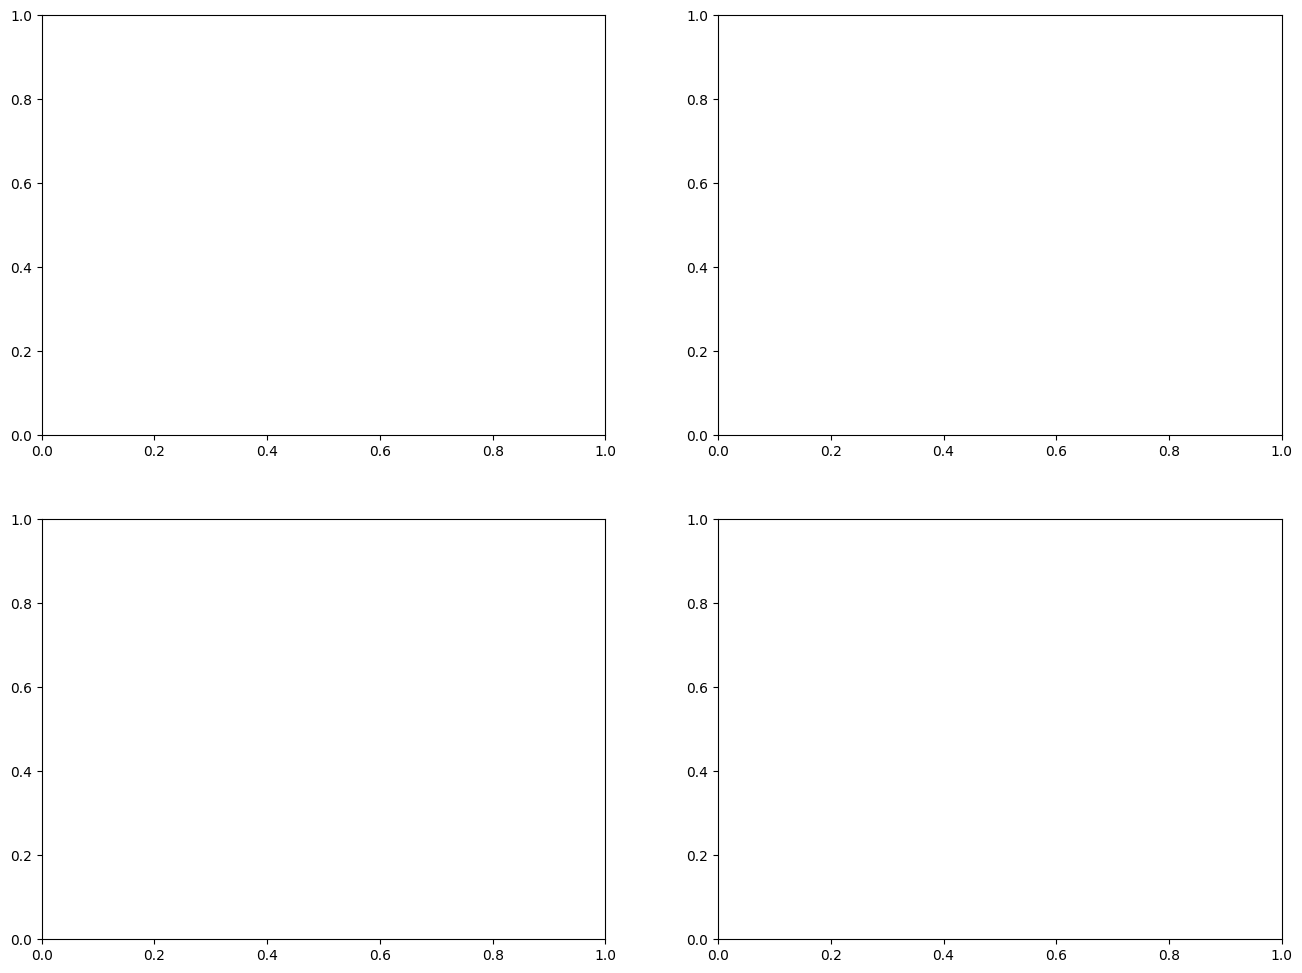

In [17]:
# Run on a few images to check consistency
sample_indices = [0, 10, 25, 40]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, ax in zip(sample_indices, axes):
    if idx >= len(image_paths):
        continue
    img = cv2.imread(image_paths[idx])
    
    # Generate the color-corrected version
    
    
    # Segment and detect using the raw image
    m, c = segment_table(img)
    bs = detect_balls(img, m)

    vis = img.copy()
    for (x, y, r) in bs:
        # Extract color from the white-balanced version
        number, colour_name, w_ratio = classify_ball( x, y, r)
        cv2.circle(vis, (x, y), r, (0, 255, 0), 2)
        cv2.putText(vis, f"#{number}", (x - r, y - r - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{os.path.basename(image_paths[idx])} — {len(bs)} balls")
    ax.axis("off")

plt.tight_layout()
plt.show()

#### 6.2. Ball number dictionary
[[go back to the topic]](#6-identify-ball-number-by-colour-and-white-ratio)

A reference dictionary mapping ball numbers to their properties.
This is handy for validation and for the JSON output.

In [27]:
# Reference dictionary: ball number -> expected properties
BALL_REFERENCE = {
    0:  {"colour": "white",  "type": "cue"},
    1:  {"colour": "yellow", "type": "solid"},
    2:  {"colour": "blue",   "type": "solid"},
    3:  {"colour": "red",    "type": "solid"},
    4:  {"colour": "purple", "type": "solid"},
    5:  {"colour": "orange", "type": "solid"},
    6:  {"colour": "green",  "type": "solid"},
    7:  {"colour": "maroon", "type": "solid"},
    8:  {"colour": "black",  "type": "8-ball"},
    9:  {"colour": "yellow", "type": "stripe"},
    10: {"colour": "blue",   "type": "stripe"},
    11: {"colour": "red",    "type": "stripe"},
    12: {"colour": "purple", "type": "stripe"},
    13: {"colour": "orange", "type": "stripe"},
    14: {"colour": "green",  "type": "stripe"},
    15: {"colour": "maroon", "type": "stripe"},
}

| #  | Colour  | Type   |
|----|---------|--------|
| 0  | white   | cue    |
| 1  | yellow  | solid  |
| 2  | blue    | solid  |
| 3  | red     | solid  |
| 4  | purple  | solid  |
| 5  | orange  | solid  |
| 6  | green   | solid  |
| 7  | maroon  | solid  |
| 8  | black   | 8-ball |
| 9  | yellow  | stripe |
| 10 | blue    | stripe |
| 11 | red     | stripe |
| 12 | purple  | stripe |
| 13 | orange  | stripe |
| 14 | green   | stripe |
| 15 | maroon  | stripe |

### 7. Ground Truth Generation
[[go back to the top]](#table-of-contents)

In [ ]:
# Run the annotation tool on the 'data' folder
# Since this function is imported from utils.py, we just call it directly
df_ground_truth = annotate_image_dataset("data")

# Display the first few rows to verify
print(df_ground_truth.head())

# Save the results to a CSV file in the root directory
df_ground_truth.to_csv("ground_truth_counts.csv", index=False)

Empty DataFrame
Columns: [filename, ball_count]
Index: []


### 8. Bounding Box Generation
[[go back to the top]](#table-of-contents)

The project specifications explicitly require the position of the balls to be output as bounding boxes. 
Since our detection algorithm operates on circles (center coordinates and radius), we need to mathematically convert these into rectangular bounding boxes `[xmin, ymin, xmax, ymax]`.

We also ensure that the bounding box coordinates do not exceed the actual image dimensions.

### 8.1 interface

In [65]:
import os
import json
import cv2
import numpy as np
import ipywidgets as widgets

from pathlib import Path
from IPython.display import display
from collections import defaultdict


# ============================================================
# Configuration
# ============================================================

BALL_LABEL_TO_NUMBER = {
    "cue": 0,
    "yellow_solid": 1,
    "blue_solid": 2,
    "red_solid": 3,
    "purple_solid": 4,
    "orange_solid": 5,
    "green_solid": 6,
    "maroon_solid": 7,
    "black": 8,
    "yellow_stripe": 9,
    "blue_stripe": 10,
    "red_stripe": 11,
    "purple_stripe": 12,
    "orange_stripe": 13,
    "green_stripe": 14,
    "maroon_stripe": 15,
}

LABELS = [
    "cue",
    "black",
    "yellow_solid",
    "yellow_stripe",
    "blue_solid",
    "blue_stripe",
    "red_solid",
    "red_stripe",
    "purple_solid",
    "purple_stripe",
    "orange_solid",
    "orange_stripe",
    "green_solid",
    "green_stripe",
    "maroon_solid",
    "maroon_stripe",
    "not_ball",
    "skip",
    "stop_and_save",
]

DISPLAY_SCALE = 4
INNER_RADIUS_FACTOR = 0.7
ROI_PAD = 2.0
AUTOSAVE_EVERY = 20

WHITE_LOW = np.array([0, 0, 160], dtype=np.uint8)
WHITE_HIGH = np.array([179, 70, 255], dtype=np.uint8)

BLACK_LOW = np.array([0, 0, 0], dtype=np.uint8)
BLACK_HIGH = np.array([179, 255, 55], dtype=np.uint8)


# ============================================================
# Optional white balance
# ============================================================

def gray_world_white_balance(img_bgr):
    """
    Simple gray-world white balance.
    """
    img = img_bgr.astype(np.float32)

    b_mean = img[:, :, 0].mean()
    g_mean = img[:, :, 1].mean()
    r_mean = img[:, :, 2].mean()

    gray_mean = (b_mean + g_mean + r_mean) / 3.0

    img[:, :, 0] *= gray_mean / max(b_mean, 1e-6)
    img[:, :, 1] *= gray_mean / max(g_mean, 1e-6)
    img[:, :, 2] *= gray_mean / max(r_mean, 1e-6)

    return np.clip(img, 0, 255).astype(np.uint8)


# ============================================================
# ROI extraction and feature computation
# ============================================================

def crop_ball_roi(img_bgr, x, y, r, pad=ROI_PAD):
    """
    Crop a square ROI around the detected ball.
    """
    h, w = img_bgr.shape[:2]

    rr = int(round(r * pad))
    x1 = max(0, int(round(x - rr)))
    y1 = max(0, int(round(y - rr)))
    x2 = min(w, int(round(x + rr)))
    y2 = min(h, int(round(y + rr)))

    roi = img_bgr[y1:y2, x1:x2].copy()
    return roi, x1, y1, x2, y2


def build_inner_circle_mask(roi_shape, radius_factor=INNER_RADIUS_FACTOR):
    """
    Inner circular mask to avoid cloth contamination.
    """
    h, w = roi_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    cx = w // 2
    cy = h // 2
    radius = int(min(cx, cy) * radius_factor)

    cv2.circle(mask, (cx, cy), radius, 255, -1)
    return mask

def compute_relative_features(row, cloth_hsv_per_image):
    """
    cloth_hsv_per_image: dict {filename: (h_cloth, s_cloth, v_cloth)}
    """
    cloth_h, cloth_s, cloth_v = cloth_hsv_per_image.get(row["filename"], (0, 0, 0))

    h = row["h_median"] or 0.0
    s = row["s_median"] or 0.0
    v = row["v_median"] or 0.0

    # Delta de hue circular
    delta_h = float(h) - float(cloth_h)
    if delta_h > 90:  delta_h -= 180
    if delta_h < -90: delta_h += 180

    delta_v = float(v) - float(cloth_v)
    ratio_s  = float(s) / max(float(cloth_s), 1.0)

    return delta_h, delta_v, ratio_s

def compute_patch_statistics(roi_bgr):
    """
    Compute robust colour statistics from the ROI.
    HSV statistics are computed only on non-white and non-black pixels.
    """
    if roi_bgr is None or roi_bgr.size == 0:
        return None

    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    circle_mask = build_inner_circle_mask(roi_bgr.shape)

    white_mask = cv2.inRange(hsv, WHITE_LOW, WHITE_HIGH)
    white_mask = cv2.bitwise_and(white_mask, circle_mask)

    black_mask = cv2.inRange(hsv, BLACK_LOW, BLACK_HIGH)
    black_mask = cv2.bitwise_and(black_mask, circle_mask)

    colour_mask = cv2.bitwise_and(
        circle_mask,
        cv2.bitwise_not(cv2.bitwise_or(white_mask, black_mask))
    )

    total_pixels = cv2.countNonZero(circle_mask)
    white_pixels = cv2.countNonZero(white_mask)
    black_pixels = cv2.countNonZero(black_mask)
    colour_pixels = cv2.countNonZero(colour_mask)

    white_ratio = white_pixels / max(total_pixels, 1)
    black_ratio = black_pixels / max(total_pixels, 1)
    colour_ratio = colour_pixels / max(total_pixels, 1)

    stats = {
        "white_ratio": float(white_ratio),
        "black_ratio": float(black_ratio),
        "colour_ratio": float(colour_ratio),
        "total_pixels": int(total_pixels),
        "colour_pixels": int(colour_pixels),
    }

    if colour_pixels > 0:
        h_vals = hsv[:, :, 0][colour_mask > 0]
        s_vals = hsv[:, :, 1][colour_mask > 0]
        v_vals = hsv[:, :, 2][colour_mask > 0]

        stats["h_median"] = float(np.median(h_vals))
        stats["s_median"] = float(np.median(s_vals))
        stats["v_median"] = float(np.median(v_vals))

        stats["h_mean"] = float(np.mean(h_vals))
        stats["s_mean"] = float(np.mean(s_vals))
        stats["v_mean"] = float(np.mean(v_vals))

    

        stats["h_values_preview"] = [int(x) for x in np.percentile(h_vals, [10, 50, 90])]
        stats["s_values_preview"] = [int(x) for x in np.percentile(s_vals, [10, 50, 90])]
        stats["v_values_preview"] = [int(x) for x in np.percentile(v_vals, [10, 50, 90])]

        stats["h_p10"]  = float(np.percentile(h_vals, 10))
        stats["h_p90"]  = float(np.percentile(h_vals, 90))
        stats["h_std"]  = float(np.std(h_vals))

        stats["s_p10"]  = float(np.percentile(s_vals, 10))
        stats["s_p90"]  = float(np.percentile(s_vals, 90))

        stats["v_p10"]  = float(np.percentile(v_vals, 10))
        stats["v_p90"]  = float(np.percentile(v_vals, 90))
        stats["v_std"]  = float(np.std(v_vals))
    # Replace the end of compute_patch_statistics(roi_bgr) starting from the 'else' block
    else:
        stats["h_median"] = None
        stats["s_median"] = None
        stats["v_median"] = None
        stats["h_mean"] = None
        stats["s_mean"] = None
        stats["v_mean"] = None
        stats["h_values_preview"] = []
        stats["s_values_preview"] = []
        stats["v_values_preview"] = []

    # Calculate spatial white distribution to differentiate solids from stripes
    stripe_score, ratio_center, ratio_ring = compute_stripe_score(roi_bgr)
    
    stats["stripe_score"] = float(stripe_score)
    stats["white_ratio_center"] = float(ratio_center)
    stats["white_ratio_ring"] = float(ratio_ring)

    return stats

    
    
def compute_stripe_score(roi_bgr, r_factor_inner=0.45, r_factor_outer=0.75):
    """
    Retorna ratio de pixels brancos no anel vs centro.
    Stripe: anel tem muito mais branco que centro.
    Solid:  distribuição mais uniforme.
    """
    h, w = roi_bgr.shape[:2]
    cx, cy = w // 2, h // 2

    r_inner = int(min(cx, cy) * r_factor_inner)
    r_outer = int(min(cx, cy) * r_factor_outer)

    mask_inner = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mask_inner, (cx, cy), r_inner, 255, -1)

    mask_outer = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mask_outer, (cx, cy), r_outer, 255, -1)
    mask_ring = cv2.bitwise_and(mask_outer, cv2.bitwise_not(mask_inner))

    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)

    WHITE_LOW  = np.array([0,   0, 160], dtype=np.uint8)
    WHITE_HIGH = np.array([179, 70, 255], dtype=np.uint8)
    white_mask = cv2.inRange(hsv, WHITE_LOW, WHITE_HIGH)

    white_in_center = cv2.countNonZero(cv2.bitwise_and(white_mask, mask_inner))
    white_in_ring   = cv2.countNonZero(cv2.bitwise_and(white_mask, mask_ring))

    total_center = max(cv2.countNonZero(mask_inner), 1)
    total_ring   = max(cv2.countNonZero(mask_ring), 1)

    ratio_center = white_in_center / total_center
    ratio_ring   = white_in_ring   / total_ring

    # Score alto = mais branco no anel = provável stripe
    stripe_score = ratio_ring - ratio_center
    return float(stripe_score), float(ratio_center), float(ratio_ring)

def draw_preview_patch(roi_bgr, detected_idx=None, total_detected=None):
    """
    Create a larger preview image for notebook display.
    """
    preview = roi_bgr.copy()

    mask = build_inner_circle_mask(preview.shape)

    overlay = preview.copy()
    overlay[mask == 0] = (40, 40, 40)
    preview = cv2.addWeighted(preview, 0.65, overlay, 0.35, 0)

    h, w = preview.shape[:2]
    preview = cv2.resize(
        preview,
        (w * DISPLAY_SCALE, h * DISPLAY_SCALE),
        interpolation=cv2.INTER_LINEAR
    )

    if detected_idx is not None and total_detected is not None:
        text = f"Detection {detected_idx + 1}/{total_detected}"
        cv2.putText(
            preview,
            text,
            (10, 25),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2,
            cv2.LINE_AA
        )

    return preview


# ============================================================
# Main annotator
# ============================================================

class BallCalibrationAnnotator:
    def __init__(
        self,
        image_paths,
        mask_fn,
        output_json="color_calibration.json",
        use_white_balance=True
    ):
        self.image_paths = [str(p) for p in image_paths]
        self.mask_fn = mask_fn
        self.output_json = output_json
        self.use_white_balance = use_white_balance

        self.samples = defaultdict(list)
        self.records = []

        self.current_image_idx = 0
        self.current_detection_idx = 0

        self.current_img_original = None
        self.current_img_balanced = None
        self.current_detections = []
        self.current_roi = None
        self.current_stats = None
        self.current_detection = None

        self.image_widget = widgets.Image(format="jpeg")
        self.full_image_widget = widgets.Image(format="jpeg")
        self.info_html = widgets.HTML()
        self.progress_html = widgets.HTML()

        self.buttons = []
        self._build_ui()
        self._load_next_valid_image()
        self._show_current_detection()

    def _make_button_handler(self, label):
        def handler(_):
            self._save_current_label(label)
        return handler

    def _build_ui(self):
        """
        Build button-based notebook UI.
        """
        label_colors = {
            "cue": "#f5f5f5",
            "black": "#222222",

            "yellow_solid": "#f4d03f",
            "yellow_stripe": "#f4d03f",

            "blue_solid": "#3498db",
            "blue_stripe": "#3498db",

            "red_solid": "#e74c3c",
            "red_stripe": "#e74c3c",

            "purple_solid": "#9b59b6",
            "purple_stripe": "#9b59b6",

            "orange_solid": "#e67e22",
            "orange_stripe": "#e67e22",

            "green_solid": "#27ae60",
            "green_stripe": "#27ae60",

            "maroon_solid": "#800000",
            "maroon_stripe": "#800000",

            "not_ball": "#7f8c8d",
            "skip": "#95a5a6",
            "stop_and_save": "#2c3e50",
        }

        dark_text_labels = {
            "cue",
            "yellow_solid",
            "yellow_stripe",
            "orange_solid",
            "orange_stripe",
        }

        self.buttons = []

        for label in LABELS:
            btn = widgets.Button(
                description=label,
                layout=widgets.Layout(width="170px", height="42px")
            )

            btn.style.button_color = label_colors.get(label, "#d3d3d3")

            if label in dark_text_labels:
                btn.style.text_color = "black"
            else:
                btn.style.text_color = "white"

            btn.on_click(self._make_button_handler(label))
            self.buttons.append(btn)

        buttons_grid = widgets.GridBox(
            self.buttons,
            layout=widgets.Layout(
                grid_template_columns="repeat(3, 180px)",
                grid_gap="8px 8px"
            )
        )

        images_box = widgets.HBox(
            [self.image_widget, self.full_image_widget],
            layout=widgets.Layout(align_items="flex-start", gap="20px")
        )

        display(self.progress_html)
        display(self.info_html)
        display(images_box)
        display(buttons_grid)

    def _build_counts_by_image(self):
        counts_by_image = {}

        valid_ball_labels = set(BALL_LABEL_TO_NUMBER.keys())

        for record in self.records:
            filename = Path(record["image_path"]).name
            label = record["label"]

            if filename not in counts_by_image:
                counts_by_image[filename] = {
                    "ball_count": 0,
                    **{ball_label: 0 for ball_label in BALL_LABEL_TO_NUMBER.keys()}
                }

            if label in valid_ball_labels:
                counts_by_image[filename][label] += 1
                counts_by_image[filename]["ball_count"] += 1

        return counts_by_image
        
    


    def _build_detections_by_image(self):
        detections_by_image = {}

        for record in self.records:
            filename = Path(record["image_path"]).name
            label = record["label"]
            x = int(record["x"])
            y = int(record["y"])
            r = int(record["r"])

            if filename not in detections_by_image:
                detections_by_image[filename] = {
                    "detections": []
                }

            if label in BALL_LABEL_TO_NUMBER:
                ball_number = BALL_LABEL_TO_NUMBER[label]
                is_real_ball = True
                is_false_detection = False
                was_skipped = False
            elif label in {"not_ball", "corner", "off_table"}:
                ball_number = None
                is_real_ball = False
                is_false_detection = True
                was_skipped = False
            elif label == "skip":
                ball_number = None
                is_real_ball = False
                is_false_detection = False
                was_skipped = True
            else:
                ball_number = None
                is_real_ball = False
                is_false_detection = False
                was_skipped = False

            if label.endswith("_solid"):
                ball_type = "solid"
                base_colour = label.replace("_solid", "")
            elif label.endswith("_stripe"):
                ball_type = "stripe"
                base_colour = label.replace("_stripe", "")
            elif label == "cue":
                ball_type = "cue"
                base_colour = "white"
            elif label == "black":
                ball_type = "black"
                base_colour = "black"
            else:
                ball_type = None
                base_colour = None

            bbox = [x - r, y - r, x + r, y + r]

            detections_by_image[filename]["detections"].append({
                "detection_index": int(record["detection_index"]),
                "x": x,
                "y": y,
                "r": r,
                "bbox": bbox,
                "label": label,
                "ball_number": ball_number,
                "ball_type": ball_type,
                "base_colour": base_colour,
                "is_real_ball": is_real_ball,
                "is_false_detection": is_false_detection,
                "was_skipped": was_skipped,
                "stats": record["stats"],
            })

        return detections_by_image

    

    def draw_full_image_preview(self, img_bgr, detections, current_idx):
        """
        Draw the full image with all detections.
        Current detection is red, others are green.
        """
        vis = img_bgr.copy()

        for i, (x, y, r) in enumerate(detections):
            if i == current_idx:
                color = (0, 0, 255)
                thickness = 3
            else:
                color = (0, 255, 0)
                thickness = 2

            cv2.circle(vis, (x, y), r, color, thickness)
            cv2.circle(vis, (x, y), 2, color, -1)
            cv2.putText(
                vis,
                str(i + 1),
                (x + 5, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                color,
                1,
                cv2.LINE_AA
            )

        max_width = 500
        h, w = vis.shape[:2]
        if w > max_width:
            scale = max_width / w
            vis = cv2.resize(
                vis,
                (int(w * scale), int(h * scale)),
                interpolation=cv2.INTER_LINEAR
            )

        return vis

    def _load_image_and_detections(self, image_path):
        """
        Load image, compute table mask, optionally white-balance it,
        and detect balls using the original image.
        """
        img_bgr = cv2.imread(image_path)
        if img_bgr is None:
            return None, None, []

        table_mask = self.mask_fn(img_bgr)
        if table_mask is None:
            return img_bgr, img_bgr.copy(), []

        balanced = gray_world_white_balance(img_bgr) if self.use_white_balance else img_bgr.copy()

        detections = detect_balls(img_bgr, table_mask)

        if detections is None:
            detections = []

        detections = np.array(detections)

        if detections.ndim == 3 and detections.shape[0] == 1:
            detections = detections[0]

        if detections.size == 0:
            detections = []
        else:
            detections = [tuple(map(int, d[:3])) for d in detections]

        return img_bgr, balanced, detections

    def _load_next_valid_image(self):
        """
        Move until finding an image with at least one detection.
        """
        while self.current_image_idx < len(self.image_paths):
            image_path = self.image_paths[self.current_image_idx]
            img_original, img_balanced, detections = self._load_image_and_detections(image_path)

            if img_original is None:
                self.current_image_idx += 1
                continue

            if len(detections) == 0:
                self.current_image_idx += 1
                continue

            self.current_img_original = img_original
            self.current_img_balanced = img_balanced
            self.current_detections = detections
            self.current_detection_idx = 0
            return

        self.current_img_original = None
        self.current_img_balanced = None
        self.current_detections = []
        self.current_detection_idx = 0

    def _advance(self):
        """
        Advance to the next detection, then next image if needed.
        """
        self.current_detection_idx += 1

        if self.current_detection_idx >= len(self.current_detections):
            self.current_image_idx += 1
            self._load_next_valid_image()

        self._show_current_detection()

    def _stop_and_save(self):
        """
        Save progress and stop annotation.
        """
        self._save_json()

        self.progress_html.value = (
            f"<b>Stopped by user.</b><br>"
            f"Images seen up to: {self.current_image_idx + 1}/{len(self.image_paths)}<br>"
            f"Saved labels: {len(self.records)}<br>"
            f"Output file: <code>{self.output_json}</code>"
        )

        self.info_html.value = "<b>Annotation stopped. Progress was saved.</b>"
        self.image_widget.value = b""
        self.full_image_widget.value = b""

        for btn in self.buttons:
            btn.disabled = True

        self.current_img_original = None
        self.current_img_balanced = None
        self.current_detections = []
        self.current_detection = None
        self.current_stats = None

    def _save_current_label(self, label):
        if label == "stop_and_save":
            self._stop_and_save()
            return

        if self.current_detection is None or self.current_stats is None:
            return

        image_path = self.image_paths[self.current_image_idx]
        x, y, r = self.current_detection

        record = {
            "image_path": image_path,
            "detection_index": int(self.current_detection_idx),
            "x": int(x),
            "y": int(y),
            "r": int(r),
            "label": label,
            "stats": self.current_stats,
        }

        self.records.append(record)
        INVALID_LABELS = {"skip", "not_ball", "corner", "off_table"}
        if label not in INVALID_LABELS:
            self.samples[label].append({
                "image_path": image_path,
                "x": int(x),
                "y": int(y),
                "r": int(r),
                **self.current_stats
            })

        if len(self.records) % AUTOSAVE_EVERY == 0:
            self._save_json()

        self._advance()

    def _show_current_detection(self):
        """
        Render current detection in notebook.
        """
        if self.current_img_balanced is None or len(self.current_detections) == 0:
            self.progress_html.value = (
                f"<b>Finished.</b><br>"
                f"Images processed: {len(self.image_paths)}<br>"
                f"Saved labels: {len(self.records)}<br>"
                f"Output file: <code>{self.output_json}</code>"
            )
            self.info_html.value = ""
            self.image_widget.value = b""
            self.full_image_widget.value = b""
            self._save_json()
            return

        image_path = self.image_paths[self.current_image_idx]
        x, y, r = self.current_detections[self.current_detection_idx]
        self.current_detection = (x, y, r)

        roi_bgr, _, _, _, _ = crop_ball_roi(self.current_img_balanced, x, y, r, pad=ROI_PAD)
        self.current_roi = roi_bgr
        self.current_stats = compute_patch_statistics(roi_bgr)

        preview = draw_preview_patch(
            roi_bgr,
            detected_idx=self.current_detection_idx,
            total_detected=len(self.current_detections)
        )

        ok_roi, encoded_roi = cv2.imencode(".jpg", preview)
        if ok_roi:
            self.image_widget.value = encoded_roi.tobytes()

        full_preview = self.draw_full_image_preview(
            self.current_img_original,
            self.current_detections,
            self.current_detection_idx
        )

        ok_full, encoded_full = cv2.imencode(".jpg", full_preview)
        if ok_full:
            self.full_image_widget.value = encoded_full.tobytes()

        self.progress_html.value = (
            f"<b>Image</b>: {self.current_image_idx + 1}/{len(self.image_paths)}"
            f" &nbsp; | &nbsp; "
            f"<b>Detection</b>: {self.current_detection_idx + 1}/{len(self.current_detections)}"
            f" &nbsp; | &nbsp; "
            f"<b>Total saved</b>: {len(self.records)}"
        )

        stats = self.current_stats
        self.info_html.value = (
            f"<b>File:</b> <code>{Path(image_path).name}</code><br>"
            f"<b>Circle:</b> x={x}, y={y}, r={r}<br>"
            f"<b>white_ratio:</b> {stats['white_ratio']:.3f} &nbsp; "
            f"<b>black_ratio:</b> {stats['black_ratio']:.3f} &nbsp; "
            f"<b>colour_ratio:</b> {stats['colour_ratio']:.3f}<br>"
            f"<b>HSV medians (colour only):</b> "
            f"H={stats['h_median']}, S={stats['s_median']}, V={stats['v_median']}"
        )

    def _save_json(self):
        """
        Save:
        1. calibration json
        2. counts by image json
        3. detailed detections by image json
        """
        compact = {}

        for label, items in self.samples.items():
            compact[label] = {
                "h": [item["h_median"] for item in items if item["h_median"] is not None],
                "s": [item["s_median"] for item in items if item["s_median"] is not None],
                "v": [item["v_median"] for item in items if item["v_median"] is not None],
                "white_ratio": [item["white_ratio"] for item in items],
                "black_ratio": [item["black_ratio"] for item in items],
                "colour_ratio": [item["colour_ratio"] for item in items],
                "samples": len(items),
            }

        calibration_payload = {
            "metadata": {
                "total_images": len(self.image_paths),
                "total_annotations": len(self.records),
                "labels": LABELS,
                "white_balance": self.use_white_balance,
                "inner_radius_factor": INNER_RADIUS_FACTOR,
                "roi_pad": ROI_PAD,
            },
            "compact_calibration": compact,
            "raw_annotations": self.records,
        }

        counts_by_image = self._build_counts_by_image()
        detections_by_image = self._build_detections_by_image()

        with open(self.output_json, "w", encoding="utf-8") as f:
            json.dump(calibration_payload, f, indent=4)

        counts_json_path = str(Path(self.output_json).with_name("ball_counts_by_image.json"))
        with open(counts_json_path, "w", encoding="utf-8") as f:
            json.dump(counts_by_image, f, indent=4)

        detections_json_path = str(Path(self.output_json).with_name("ball_annotations_by_image.json"))
        with open(detections_json_path, "w", encoding="utf-8") as f:
            json.dump(detections_by_image, f, indent=4)

        print(f"Saved calibration JSON to: {self.output_json}")
        print(f"Saved counts-by-image JSON to: {counts_json_path}")
        print(f"Saved detections-by-image JSON to: {detections_json_path}")

In [154]:
IMAGE_DIR = Path("development_set")

image_paths = sorted(
    [p for p in IMAGE_DIR.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}]
)
''' If you want to select a specific image - If you run, pay attention to the output json files :)
TARGET_IMAGES = {
    "21a_png.rf.34ea0016904d75da861731071be2058f.jpg",
    "23a_png.rf.c51e6e9452d0f5b24425c277e7e93085.jpg",
    "123_png.rf.c77820fd3abbca5d6265af63564f9564.jpg",
    "127_png.rf.9f6501b0ba0e856cf6dd9e59f65ce574.jpg",
}
'''

image_paths = sorted(
    [p for p in IMAGE_DIR.glob("*") if p.name in TARGET_IMAGES]
)

print(f"Found {len(image_paths)} images")


def get_table_mask(img_bgr):
    mask, _ = segment_table(img_bgr)
    return mask

'''
annotator = BallCalibrationAnnotator(
    image_paths=image_paths,
    mask_fn=get_table_mask,
    output_json="color_calibration.json",
    use_white_balance=True
)
'''

Found 4 images


'\nannotator = BallCalibrationAnnotator(\n    image_paths=image_paths,\n    mask_fn=get_table_mask,\n    output_json="color_calibration.json",\n    use_white_balance=True\n)\n'

# Final run code 

In [66]:
import json
from pathlib import Path
from collections import defaultdict, Counter

import cv2
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    recall_score,
)
import numpy as np


# ============================================================
# Configuration
# ============================================================

IMAGE_DIR = Path("development_set")
ANNOTATIONS_JSON = Path("ball_annotations_by_image_v2.json")
OUTPUT_JSON = Path("full_pipeline_predictions_v1.json")

VALID_LABELS = {
    "cue",
    "yellow_solid", "blue_solid", "red_solid", "purple_solid",
    "orange_solid", "green_solid", "maroon_solid", "black",
    "yellow_stripe", "blue_stripe", "red_stripe", "purple_stripe",
    "orange_stripe", "green_stripe", "maroon_stripe",
}
INVALID_LABELS = {"not_ball", "skip", "corner", "off_table"}

CHROMATIC_CLASSES = ["yellow", "blue", "red", "purple", "orange", "green", "maroon"]
REQUIRED_UNIQUE_LABELS = ["cue", "black"]

FEATURE_NAMES = [
    "hue_cos",
    "hue_sin",
    "s_median",
    "v_median",
    "white_ratio",
    "black_ratio",
    "colour_ratio",
    "h_std",
    "v_p90",
    "v_std",
    "s_p90",
    "stripe_score",
]

KNN_K = 5
COLOUR_CONFIDENCE_MIN_FOR_REASSIGN = 0.00
TYPE_CONFIDENCE_MIN_FOR_REASSIGN = 0.08

# Stage 1: validity rules
VALIDITY_THRESHOLDS = {
    "not_ball_white_ratio_max": 0.020,
    "not_ball_black_ratio_min": 0.180,
    "not_ball_h_std_max": 12.0,
    "suspect_white_ratio_center_min": 0.20,
    "suspect_center_minus_ring_min": 0.10,
    "ball_colour_ratio_min": 0.78,
    "ball_h_std_min": 18.0,
}

VALIDITY_WEIGHTS = {
    "very_low_white_ratio": -2.0,
    "high_black_ratio": -1.5,
    "low_h_std": -1.0,
    "high_white_ratio_center": -0.8,
    "high_center_minus_ring": -0.6,
    "good_colour_ratio": 0.8,
    "nonzero_white_ratio": 0.5,
    "good_h_std": 0.5,
}

VALIDITY_SCORE_THRESHOLDS = {
    "invalid_detection": -4.0,
    "suspect": -0.8,
}

# Stage 2: base colour rules
BLACK_RATIO_MIN_FOR_BLACK = 0.22
WHITE_RATIO_MIN_FOR_WHITE = 0.20
WHITE_VP90_MIN = 205.0
WHITE_S_MEDIAN_MAX = 170.0
WHITE_BLACK_RATIO_MAX = 0.08

# Stage 4: global consistency
GLOBAL_WEIGHTS = {
    "final_conf": 2.0,
    "base_conf": 0.5,
    "type_conf": 0.3,
    "validity_score": 0.8,
    "penalty_invalid": -100.0,
    "penalty_suspect": -1.5,
}



# ============================================================
# Generic helpers
# ============================================================

def safe_float(value, default=0.0):
    if value is None:
        return float(default)
    try:
        if np.isnan(value):
            return float(default)
    except Exception:
        pass
    return float(value)


def label_to_base_colour(label):
    if label == "cue":
        return "white"
    if label == "black":
        return "black"
    if label.endswith("_solid"):
        return label.replace("_solid", "")
    if label.endswith("_stripe"):
        return label.replace("_stripe", "")
    return None


def label_to_ball_type(label):
    if label == "cue":
        return "cue"
    if label == "black":
        return "black"
    if label.endswith("_solid"):
        return "solid"
    if label.endswith("_stripe"):
        return "stripe"
    return None


def final_label_from_parts(base_colour, ball_type):
    if base_colour == "white":
        return "cue"
    if base_colour == "black":
        return "black"
    if base_colour is None or ball_type is None:
        return "not_ball"
    return f"{base_colour}_{ball_type}"


def circular_mean_hue_opencv(h_values):
    clean = []
    for v in h_values:
        if v is None:
            continue
        try:
            if np.isnan(v):
                continue
        except Exception:
            pass
        clean.append(float(v))

    if not clean:
        return None

    angles = np.asarray(clean, dtype=float) * 2.0 * np.pi / 180.0
    angle = np.arctan2(np.mean(np.sin(angles)), np.mean(np.cos(angles)))
    if angle < 0:
        angle += 2.0 * np.pi
    return float(angle * 180.0 / (2.0 * np.pi))


def circular_hue_diff(h1, h2):
    diff = abs(float(h1) - float(h2))
    return min(diff, 180.0 - diff)


# ============================================================
# Load annotations
# ============================================================

def load_annotations(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        return json.load(f)


def build_detection_row(det, filename):
    stats = det.get("stats", {})

    white_ratio_center = safe_float(stats.get("white_ratio_center"), 0.0)
    white_ratio_ring = safe_float(stats.get("white_ratio_ring"), 0.0)

    row = {
        "filename": filename,
        "detection_index": int(det.get("detection_index", -1)),
        "x": int(det.get("x", -1)),
        "y": int(det.get("y", -1)),
        "r": int(det.get("r", -1)),
        "label_gt": det.get("label"),

        "white_ratio": stats.get("white_ratio"),
        "black_ratio": stats.get("black_ratio"),
        "colour_ratio": stats.get("colour_ratio"),
        "h_median": stats.get("h_median"),
        "s_median": stats.get("s_median"),
        "v_median": stats.get("v_median"),
        "h_p10": stats.get("h_p10"),
        "h_p90": stats.get("h_p90"),
        "h_std": stats.get("h_std"),
        "s_p90": stats.get("s_p90"),
        "v_p90": stats.get("v_p90"),
        "v_std": stats.get("v_std"),
        "stripe_score": stats.get("stripe_score"),
        "white_ratio_center": stats.get("white_ratio_center"),
        "white_ratio_ring": stats.get("white_ratio_ring"),
        "white_center_minus_ring": white_ratio_center - white_ratio_ring,
    }

    return row


# ============================================================
# Stage 2 training set for base colour
# Uses your current feature set and rules
# ============================================================

def build_base_colour_training_rows(annotations_by_image):
    rows = []

    for filename, payload in annotations_by_image.items():
        for det in payload.get("detections", []):
            label = det.get("label")
            if label not in VALID_LABELS:
                continue
            if not det.get("is_real_ball", False):
                continue

            row = build_detection_row(det, filename)
            row["base_colour"] = det.get("base_colour") or label_to_base_colour(label)
            row["ball_type"] = det.get("ball_type") or label_to_ball_type(label)
            rows.append(row)

    return rows


def robust_filter_group(rows, colour_name):
    if not rows:
        return []

    if colour_name == "white":
        vals_white = [safe_float(r["white_ratio"], 0.0) for r in rows]
        vals_v = [safe_float(r["v_median"], 0.0) for r in rows]
        q_white = np.quantile(vals_white, 0.05)
        q_v = np.quantile(vals_v, 0.05)

        return [
            r for r in rows
            if safe_float(r["white_ratio"], 0.0) >= q_white
            and safe_float(r["v_median"], 0.0) >= q_v
        ]

    if colour_name == "black":
        vals_black = [safe_float(r["black_ratio"], 0.0) for r in rows]
        q_black = np.quantile(vals_black, 0.10)

        return [r for r in rows if safe_float(r["black_ratio"], 0.0) >= q_black]

    vals_s = [safe_float(r["s_median"], 0.0) for r in rows]
    vals_v = [safe_float(r["v_median"], 0.0) for r in rows]

    s_lo, s_hi = np.quantile(vals_s, 0.05), np.quantile(vals_s, 0.95)
    v_lo, v_hi = np.quantile(vals_v, 0.05), np.quantile(vals_v, 0.95)

    filtered = [
        r for r in rows
        if s_lo <= safe_float(r["s_median"], 0.0) <= s_hi
        and v_lo <= safe_float(r["v_median"], 0.0) <= v_hi
    ]

    h_vals = [
        safe_float(r["h_median"], 0.0)
        for r in filtered
        if r.get("h_median") is not None
    ]
    if not h_vals:
        return filtered

    h_center = circular_mean_hue_opencv(h_vals)
    if h_center is None:
        return filtered

    dists = [circular_hue_diff(safe_float(r["h_median"], 0.0), h_center) for r in filtered]
    thr = np.quantile(dists, 0.90)

    out = []
    for r in filtered:
        dist = circular_hue_diff(safe_float(r["h_median"], 0.0), h_center)
        if dist <= thr:
            out.append(r)

    return out


def filter_training_rows(rows):
    grouped = defaultdict(list)
    for r in rows:
        grouped[r["base_colour"]].append(r)

    out = []
    for colour_name, group_rows in grouped.items():
        out.extend(robust_filter_group(group_rows, colour_name))

    return out


def build_feature_vector_from_row(row):
    h = row["h_median"] if row["h_median"] is not None else None

    h_std = safe_float(row.get("h_std"), 0.0)
    s = safe_float(row.get("s_median"), 0.0)
    s_p90 = safe_float(row.get("s_p90"), 0.0)
    v = safe_float(row.get("v_median"), 0.0)
    v_p90 = safe_float(row.get("v_p90"), 0.0)
    v_std = safe_float(row.get("v_std"), 0.0)

    white_ratio = safe_float(row.get("white_ratio"), 0.0)
    black_ratio = safe_float(row.get("black_ratio"), 0.0)
    colour_ratio = safe_float(row.get("colour_ratio"), 0.0)
    stripe_score = safe_float(row.get("stripe_score"), 0.0)

    if h is None:
        hue_cos = 0.0
        hue_sin = 0.0
    else:
        angle = 2.0 * np.pi * float(h) / 180.0
        hue_cos = np.cos(angle)
        hue_sin = np.sin(angle)

    return np.array([
        hue_cos,
        hue_sin,
        s,
        v,
        white_ratio,
        black_ratio,
        colour_ratio,
        h_std,
        v_p90,
        v_std,
        s_p90,
        stripe_score,
    ], dtype=float)


def build_training_matrix(training_rows):
    X = np.vstack([build_feature_vector_from_row(r) for r in training_rows])
    y = np.asarray([r["base_colour"] for r in training_rows], dtype=object)

    feature_mean = X.mean(axis=0)
    feature_std = X.std(axis=0)
    feature_std[feature_std == 0] = 1.0

    Xz = (X - feature_mean) / feature_std
    return Xz, y, feature_mean, feature_std


# ============================================================
# Stage 1: validity
# ============================================================


def predict_validity(row):
    """
    Soft validity scoring only.

    Strategy:
    - no hard invalid_detection
    - everything gets a score
    - strong balls get higher score
    - suspicious detections get lower score
    - dark balls are explicitly protected
    - optional table-like penalty can be used if available
    """

    white_ratio = safe_float(row.get("white_ratio"), 0.0)
    black_ratio = safe_float(row.get("black_ratio"), 0.0)
    colour_ratio = safe_float(row.get("colour_ratio"), 0.0)
    h_std = safe_float(row.get("h_std"), 0.0)
    v_std = safe_float(row.get("v_std"), 0.0)
    s_median = safe_float(row.get("s_median"), 0.0)

    white_ratio_center = safe_float(row.get("white_ratio_center"), 0.0)
    white_ratio_ring = safe_float(row.get("white_ratio_ring"), 0.0)
    white_center_minus_ring = safe_float(
        row.get("white_center_minus_ring"),
        white_ratio_center - white_ratio_ring
    )

    # Optional future feature:
    # high value = region looks too similar to table cloth
    table_like_ratio = safe_float(row.get("table_like_ratio"), 0.0)

    reasons = []
    score = 0.0

    # =========================================================
    # 1. Explicit cue protection
    # =========================================================
    likely_cue = (
        white_ratio >= 0.30
        and white_ratio_center >= 0.70
        and black_ratio <= 0.03
    )

    if likely_cue:
        score += 3.0
        reasons.append("likely_cue_pattern")

    # =========================================================
    # 2. Explicit dark-ball protection
    # =========================================================
    likely_dark_ball = (
        black_ratio >= 0.20
        and colour_ratio >= 0.60
        and v_std >= 30.0
    )
    

    if likely_dark_ball:
        score += 1.5
        reasons.append("likely_dark_ball")
    
    likely_uniform_real_ball = (
    colour_ratio >= 0.97
    and black_ratio <= 0.05
    and white_ratio_center <= 0.02
    and white_ratio <= 0.02
    and v_std >= 18.0
)

    if likely_uniform_real_ball:
        score += 1.2
        reasons.append("likely_uniform_real_ball")

    likely_dark_artifact = (
        black_ratio >= 0.30
        and h_std <= 10.0
        and white_ratio_center <= 0.02
    )

    if likely_dark_artifact:
        score -= 2.0
        reasons.append("likely_dark_artifact")

    # =========================================================
    # 3. Positive evidence for real ball
    # =========================================================
    if white_ratio_center >= 0.02:
        score += 1.0
        reasons.append("nonzero_white_center")

    if white_ratio >= 0.02:
        score += 0.5
        reasons.append("nonzero_white_ratio")

    if h_std >= 12.0:
        score += 0.6
        reasons.append("good_h_std")

    if h_std >= 20.0:
        score += 0.6
        reasons.append("very_good_h_std")

    if v_std >= 20.0:
        score += 0.8
        reasons.append("good_v_std")

    if v_std >= 40.0:
        score += 0.5
        reasons.append("very_good_v_std")

    # Small positive only
    if colour_ratio >= 0.75:
        score += 0.2
        reasons.append("good_colour_ratio_small")

    # =========================================================
    # 4. Suspicious evidence
    # =========================================================


    if h_std < 10.0 and not likely_uniform_real_ball and not likely_dark_ball:
        score -= 1.0
        reasons.append("low_h_std")

    if h_std < 5.0 and not likely_uniform_real_ball and not likely_dark_ball:
        score -= 1.2
        reasons.append("very_low_h_std")

    # High saturation + very flat region can be suspicious
    if s_median >= 180.0 and h_std < 8.0:
        score -= 0.8
        reasons.append("high_sat_flat_region")

    # White concentrated too much in center can be suspicious
    # but do not punish cue-like cases
    if white_ratio_center < 0.01 and not likely_uniform_real_ball:
        score -= 1.0
        reasons.append("very_low_white_center")

    if white_ratio < 0.01 and not likely_uniform_real_ball:
        score -= 0.6
        reasons.append("very_low_white_ratio")

    if white_center_minus_ring > 0.10 and not likely_cue:
        score -= 0.4
        reasons.append("high_center_minus_ring")

    # Dark region penalty only if it does NOT look like a dark ball
    if black_ratio > 0.22 and not likely_dark_ball:
        score -= 0.5
        reasons.append("high_black_ratio_without_dark_ball_support")

    # Optional future penalty for table-like detections
    if table_like_ratio >= 0.50:
        score -= 1.2
        reasons.append("high_table_like_ratio")

    if table_like_ratio >= 0.70:
        score -= 1.0
        reasons.append("very_high_table_like_ratio")
    likely_black_ball = (
    black_ratio >= 0.14
    and colour_ratio >= 0.60
    and v_std >= 30.0
    and white_ratio_center <= 0.03
)
    if likely_black_ball:
        score += 1.8
        reasons.append("likely_black_ball")

    # =========================================================
    # 5. Final soft class
    # =========================================================
    # We keep the same API, but avoid hard invalids.
    if score <= -2.0:
        validity_class = "suspect"
    else:
        validity_class = "valid_ball"

    return {
        "validity_class": validity_class,
        "validity_score": float(score),
        "validity_reasons": reasons,
    }


# ============================================================
# Stage 2: base colour
# ============================================================

def apply_explicit_base_colour_rules(row):
    black_ratio = safe_float(row.get("black_ratio"), 0.0)
    white_ratio = safe_float(row.get("white_ratio"), 0.0)
    colour_ratio = safe_float(row.get("colour_ratio"), 0.0)
    h_median = safe_float(row.get("h_median"), 0.0)
    v_median = safe_float(row.get("v_median"), 0.0)
    s_median = safe_float(row.get("s_median"), 0.0)
    v_p90 = safe_float(row.get("v_p90"), v_median)
    ball_type = row.get("ball_type_hint")
    # Add these two — were missing
    white_ratio_center = safe_float(row.get("white_ratio_center"), 0.0)
    white_ratio_ring   = safe_float(row.get("white_ratio_ring"), 0.0)

    # Black
    if black_ratio >= 0.12 and white_ratio <= 0.12 and v_median <= 190:
        return "black"

    # Yellow stripe
    if (
        ball_type == "stripe"
        and 0.20 <= white_ratio <= 0.27
        and black_ratio <= 0.02
        and colour_ratio >= 0.72
        and h_median <= 95
    ):
        return "yellow"

    # White/cue — white must be spread across ball, not just a center glare
    if (
        white_ratio >= 0.15
        and v_p90 >= 190
        and s_median <= 190
        and black_ratio <= 0.10
        and white_ratio_center >= 0.10
        and white_ratio >= white_ratio_center * 0.6
    ):
        return "white"

    # Chromatic hue rules to reduce red/maroon/orange confusion
    s_min_chromatic = 100
    if s_median >= s_min_chromatic and colour_ratio >= 0.55:
        if h_median <= 7 or h_median >= 173:
            return "red"
        if 7 < h_median <= 16 and v_median <= 160:
            return "maroon"
        if 8 < h_median <= 22 and v_median > 130:
            return "orange"

    return None
# ============================================================
# Stage 3: ball type
# ============================================================

def predict_ball_type_with_probabilities(row, predicted_base_colour):
    if predicted_base_colour == "white":
        return {"top1": "cue", "ranked": [("cue", 1.0)], "confidence": 1.0, "source": "forced"}
    if predicted_base_colour == "black":
        return {"top1": "black", "ranked": [("black", 1.0)], "confidence": 1.0, "source": "forced"}

    stripe_score       = safe_float(row.get("stripe_score"), 0.0)
    white_ratio        = safe_float(row.get("white_ratio"), 0.0)
    white_ratio_center = safe_float(row.get("white_ratio_center"), 0.0)
    white_ratio_ring   = safe_float(row.get("white_ratio_ring"), 0.0)
    h_std              = safe_float(row.get("h_std"), 0.0)
    colour_ratio       = safe_float(row.get("colour_ratio"), 0.0)

    # Purple-specific guard: h_std is the strongest signal (F1=0.82)
    # solid has low h_std (median=10.6), stripe has higher (median=19.9)
    if predicted_base_colour == "purple":
        if h_std < 16.0 and colour_ratio > 0.93:
            score = -5.0  # almost certainly solid — specular glare fooling stripe_score
        else:
            score = -3.5 * stripe_score  # original formula for true stripes

    # All other colours: original formula unchanged
    else:
        score = 0.0
        score -= 3.5 * stripe_score
        if stripe_score < -0.03 and white_ratio_ring > 0.01:
            score += 1.5 * (white_ratio_center - white_ratio_ring)
        score += 0.8 * (white_ratio - 0.10)

    prob_stripe = 1.0 / (1.0 + np.exp(-6.0 * score))
    prob_solid  = 1.0 - prob_stripe

    ranked = sorted(
        [("stripe", prob_stripe), ("solid", prob_solid)],
        key=lambda x: x[1], reverse=True
    )
    return {
        "top1": ranked[0][0],
        "ranked": ranked,
        "confidence": float(ranked[0][1]),
        "source": "rule_score",
    }

# ============================================================
# Local prediction bundle
# ============================================================

def build_ranked_final_predictions(base_colour_pred, ball_type_pred):
    options = []

    for colour_cls, colour_prob in base_colour_pred["ranked"]:
        type_pred_alt = ball_type_pred if colour_cls == base_colour_pred["top1"] else None

        if colour_cls in ("white", "black"):
            ranked_types = [("cue", 1.0)] if colour_cls == "white" else [("black", 1.0)]
        else:
            if type_pred_alt is None:
                ranked_types = [("solid", 0.5), ("stripe", 0.5)]
            else:
                ranked_types = type_pred_alt["ranked"]

        for type_cls, type_prob in ranked_types:
            final_label = final_label_from_parts(colour_cls, type_cls)
            joint_prob = float(colour_prob) * float(type_prob)
            options.append({
                "final_label": final_label,
                "base_colour": colour_cls,
                "ball_type": type_cls,
                "joint_prob": joint_prob,
            })

    dedup = {}
    for item in sorted(options, key=lambda d: d["joint_prob"], reverse=True):
        if item["final_label"] not in dedup:
            dedup[item["final_label"]] = item

    return list(dedup.values())
    
def predict_base_colour_with_probabilities(row, Xz_train, y_train, feature_mean, feature_std, k=KNN_K):
    rule_pred = apply_explicit_base_colour_rules(row)
    if rule_pred is not None:
        return {
            "top1": rule_pred,
            "ranked": [(rule_pred, 1.0)],
            "confidence": 1.0,
            "source": "rule",
        }

    x = build_feature_vector_from_row(row)
    xz = (x - feature_mean) / feature_std

    dists = np.linalg.norm(Xz_train - xz, axis=1)
    nn_idx = np.argsort(dists)[:k]

    votes = defaultdict(float)
    for idx in nn_idx:
        cls = y_train[idx]
        if cls in ("white", "black"):
            continue
        votes[cls] += 1.0 / max(dists[idx], 1e-6)

    if not votes:
    # all neighbours were white/black — this detection is likely cue or black
        top_cls = y_train[nn_idx[0]]
        return {"top1": top_cls, "ranked": [(top_cls, 1.0)], "confidence": 1.0, "source": "knn_fallback"}

    total = sum(votes.values())
    ranked = sorted(
        [(cls, score / total) for cls, score in votes.items()],
        key=lambda x: x[1],
        reverse=True
    )

    return {
        "top1": ranked[0][0],
        "ranked": ranked,
        "confidence": float(ranked[0][1]),
        "source": "knn",
    }


def predict_single_detection(row, Xz_train, y_train, feature_mean, feature_std):
    validity = predict_validity(row)

    base_colour_pred = predict_base_colour_with_probabilities(
        row, Xz_train, y_train, feature_mean, feature_std
    )

    ball_type_pred = predict_ball_type_with_probabilities(
        row, base_colour_pred["top1"]
    )

    ranked_final = build_ranked_final_predictions(base_colour_pred, ball_type_pred)
    pred_final_label = ranked_final[0]["final_label"] if ranked_final else "not_ball"
    pred_final_conf = ranked_final[0]["joint_prob"] if ranked_final else 0.0

    out = dict(row)
    out.update(validity)
    out["pred_base_colour"] = base_colour_pred["top1"]
    out["pred_base_colour_conf"] = float(base_colour_pred["confidence"])
    out["pred_ball_type"] = ball_type_pred["top1"]
    out["pred_ball_type_conf"] = float(ball_type_pred["confidence"])
    out["pred_final_label"] = pred_final_label
    out["pred_final_conf"] = float(pred_final_conf)
    out["ranked_final_predictions"] = ranked_final
    return out


# ============================================================
# Stage 4: global consistency
# ============================================================

def combined_strength(row):
    penalty = 0.0

    if row["validity_class"] == "suspect":
        penalty += -1.5

    return (
        GLOBAL_WEIGHTS["final_conf"] * float(row["pred_final_conf"]) +
        GLOBAL_WEIGHTS["base_conf"] * float(row["pred_base_colour_conf"]) +
        GLOBAL_WEIGHTS["type_conf"] * float(row["pred_ball_type_conf"]) +
        GLOBAL_WEIGHTS["validity_score"] * float(row["validity_score"]) +
        penalty
    )


def get_allowed_count_for_label(label):
    if label == "not_ball":
        return 999999
    if label == "cue":
        return 1
    if label == "black":
        return 1
    return 1


def get_label_prob_from_ranked(row, wanted_label):
    for opt in row["ranked_final_predictions"]:
        if opt["final_label"] == wanted_label:
            return float(opt["joint_prob"])
    return 0.0


def choose_required_candidate(rows, required_label):
    candidates = []

    for idx, row in enumerate(rows):
        prob = get_label_prob_from_ranked(row, required_label)

        if prob <= 0.0:
            continue

        # First preference: valid_ball
        tier = 0 if row["validity_class"] == "valid_ball" else (1 if row["validity_class"] == "suspect" else 2)
        score = row["strength"] + 2.0 * prob
        candidates.append((tier, score, idx, prob))

    if not candidates:
        return None

    candidates.sort(key=lambda x: (x[0], -x[1]))
    _, _, idx, prob = candidates[0]
    return idx, prob


def try_reassign_row(row, assigned_labels, forbidden_current_label=None):
    counts = Counter(assigned_labels)

    for option in row["ranked_final_predictions"]:
        cand = option["final_label"]
        prob = float(option["joint_prob"])

        if cand == forbidden_current_label:
            continue

        if cand == "not_ball":
            continue

        if counts[cand] < get_allowed_count_for_label(cand):
            return cand, prob, "reassigned"

    return row["final_global_label"], row["final_global_conf"], "kept_duplicate"

def force_required_labels(rows):
    for required_label in REQUIRED_UNIQUE_LABELS:
        winner = choose_required_candidate(rows, required_label)
        if winner is None:
            continue

        winner_idx, winner_prob = winner
        rows[winner_idx]["final_global_label"] = required_label
        rows[winner_idx]["final_global_conf"] = winner_prob
        rows[winner_idx]["global_resolution"] = f"forced_required_{required_label}"

    return rows


def resolve_overflow_conflicts(rows):
    changed = True

    while changed:
        changed = False

        grouped = defaultdict(list)
        for idx, row in enumerate(rows):
            label = row["final_global_label"]
            if label != "not_ball":
                grouped[label].append((idx, row))

        for label, items in grouped.items():
            allowed = get_allowed_count_for_label(label)
            if len(items) <= allowed:
                continue

            items = sorted(items, key=lambda x: x[1]["strength"], reverse=True)
            overflow = items[allowed:]
            overflow_indices = {idx for idx, _ in overflow}

            kept_labels = [
                rows[i]["final_global_label"]
                for i in range(len(rows))
                if rows[i]["final_global_label"] != "not_ball" and i not in overflow_indices
            ]

            for idx, row in overflow:
                new_label, new_prob, mode = try_reassign_row(
                    row,
                    kept_labels,
                    forbidden_current_label=label
                )

                if new_label != row["final_global_label"]:
                    rows[idx]["final_global_label"] = new_label
                    rows[idx]["final_global_conf"] = new_prob
                    rows[idx]["global_resolution"] = mode
                    changed = True

    return rows


def resolve_global_consistency(pred_rows):
    rows = [dict(r) for r in pred_rows]

    for row in rows:
        row["strength"] = combined_strength(row)

    for row in rows:
        row["final_global_label"] = row["pred_final_label"]
        row["final_global_conf"] = float(row["pred_final_conf"])
        row["global_resolution"] = "kept_top1"

    rows = force_required_labels(rows)
    rows = resolve_overflow_conflicts(rows)
    rows = force_required_labels(rows)
    rows = resolve_overflow_conflicts(rows)

    # Final weak-candidate demotion
    for row in rows:
        if row["final_global_label"] in ("cue", "black"):
            continue

        if (
    row["validity_class"] == "suspect"
    and row["strength"] < -1
    and row["final_global_label"] not in ("cue", "black")
):
            row["final_global_label"] = "not_ball"
            row["final_global_conf"] = 0.0
            row["global_resolution"] = "weak_suspect_demoted"



    # Strong invalid final filter (extreme negatives only)

    for row in rows:
        if row["final_global_label"] in ("cue", "black"):
            continue

        if row["validity_score"] <= -3.5:
            row["final_global_label"] = "not_ball"
            row["final_global_conf"] = 0.0
            row["global_resolution"] = "final_strong_invalid"


    return sorted(rows, key=lambda d: (d["x"], d["y"]))


# ============================================================
# Per-image prediction
# ============================================================

def predict_image_detections(filename, detections, Xz_train, y_train, feature_mean, feature_std):
    pred_rows = []

    for det in detections:
        row = build_detection_row(det, filename)
        row["ball_type_hint"] = det.get("ball_type")
        pred = predict_single_detection(row, Xz_train, y_train, feature_mean, feature_std)
        pred_rows.append(pred)

    pred_rows = resolve_global_consistency(pred_rows)
    return pred_rows


# ============================================================
# Reporting
# ============================================================

def print_counts(title, items):
    print(f"\n{title}")
    counts = Counter(items)
    for key in sorted(counts.keys()):
        print(f"{key:25s} {counts[key]}")


def print_debug_summary(all_rows):
    print_counts(
        "Final global labels:",
        [r["final_global_label"] for r in all_rows]
    )
    print_counts(
        "Global resolution modes:",
        [r["global_resolution"] for r in all_rows]
    )
    print_counts(
        "Validity classes:",
        [r["validity_class"] for r in all_rows]
    )


# ============================================================
# Main run
# ============================================================

def run_full_pipeline(
    annotations_json=ANNOTATIONS_JSON,
    output_json=OUTPUT_JSON
):
    annotations_by_image = load_annotations(annotations_json)

    training_rows = build_base_colour_training_rows(annotations_by_image)
    training_rows = filter_training_rows(training_rows)
    Xz_train, y_train, feature_mean, feature_std = build_training_matrix(training_rows)

    output = {}
    all_rows = []

    for filename, payload in annotations_by_image.items():
        detections = payload.get("detections", [])  # todas, sem filtro
    
        preds = predict_image_detections(
            filename,
            detections,
            Xz_train, y_train, feature_mean, feature_std,
    )

        output[filename] = {
            "predictions": preds
        }
        all_rows.extend(preds)

    with open(output_json, "w", encoding="utf-8") as f:
        json.dump(output, f, indent=4)

    print_debug_summary(all_rows)
    return output, all_rows, (Xz_train, y_train, feature_mean, feature_std)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [67]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np


output, all_rows, model_bundle = run_full_pipeline(
    annotations_json=ANNOTATIONS_JSON,
    output_json=OUTPUT_JSON,
)
def evaluate_final_global(all_rows):
    y_true = []
    y_pred = []

    for row in all_rows:
        gt = "valid_ball" if row["label_gt"] in VALID_LABELS else "not_valid_ball"
        pred = "not_valid_ball" if row["final_global_label"] == "not_ball" else "valid_ball"

        y_true.append(gt)
        y_pred.append(pred)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print("Balanced accuracy:", round(balanced_accuracy_score(y_true, y_pred), 4))
    print("Weighted F1:", round(f1_score(y_true, y_pred, average="weighted"), 4))
    print("Macro F1:", round(f1_score(y_true, y_pred, average="macro"), 4))
    print("Recall not_valid_ball:", round(
        recall_score(y_true, y_pred, pos_label="not_valid_ball"), 4
    ))

    print("\nConfusion matrix:")
    print(confusion_matrix(y_true, y_pred, labels=["not_valid_ball", "valid_ball"]))

    return y_true, y_pred

for row in all_rows:
    gt = "valid_ball" if row["label_gt"] in VALID_LABELS else "not_valid_ball"
    pred = row["final_global_label"]
    if gt == "valid_ball" and pred == "not_ball":
        print(
            f"FN | resolution={row['global_resolution']} "
            f"| validity_score={row['validity_score']:.2f} "
            f"| strength={row['strength']:.2f} "
            f"| validity_class={row['validity_class']}"
        )

# Depois o evaluate
evaluate_final_global(all_rows)


Final global labels:
black                     51
blue_solid                35
blue_stripe               33
cue                       60
green_solid               33
green_stripe              35
maroon_solid              31
maroon_stripe             34
not_ball                  2
orange_solid              43
orange_stripe             30
purple_solid              30
purple_stripe             31
red_solid                 32
red_stripe                25
yellow_solid              34
yellow_stripe             29

Global resolution modes:
forced_required_black     47
forced_required_cue       44
kept_top1                 405
reassigned                70
weak_suspect_demoted      2

Validity classes:
suspect                   4
valid_ball                564
Accuracy: 0.9754
Balanced accuracy: 0.5625
Weighted F1: 0.9659
Macro F1: 0.6048
Recall not_valid_ball: 0.125

Confusion matrix:
[[  2  14]
 [  0 552]]


(array(['valid_ball', 'valid_ball', 'valid_ball', 'valid_ball',
        'valid_ball', 'valid_ball', 'valid_ball', 'valid_ball',
        'valid_ball', 'valid_ball', 'valid_ball', 'valid_ball',
        'valid_ball', 'valid_ball', 'valid_ball', 'valid_ball',
        'valid_ball', 'valid_ball', 'valid_ball', 'valid_ball',
        'valid_ball', 'valid_ball', 'valid_ball', 'valid_ball',
        'valid_ball', 'valid_ball', 'valid_ball', 'valid_ball',
        'valid_ball', 'valid_ball', 'valid_ball', 'valid_ball',
        'valid_ball', 'valid_ball', 'valid_ball', 'valid_ball',
        'valid_ball', 'valid_ball', 'valid_ball', 'valid_ball',
        'valid_ball', 'valid_ball', 'valid_ball', 'valid_ball',
        'valid_ball', 'valid_ball', 'valid_ball', 'valid_ball',
        'valid_ball', 'valid_ball', 'valid_ball', 'valid_ball',
        'valid_ball', 'valid_ball', 'valid_ball', 'valid_ball',
        'valid_ball', 'valid_ball', 'valid_ball', 'valid_ball',
        'valid_ball', 'valid_ball', 'val

In [68]:
def evaluate_colour_and_type(all_rows):
    # Filtra só bolas reais com label válido
    valid_rows = [r for r in all_rows if r["label_gt"] in VALID_LABELS]

    # ── Base colour ──────────────────────────────────────────
    y_true_colour = [label_to_base_colour(r["label_gt"]) for r in valid_rows]
    y_pred_colour = [r["pred_base_colour"] for r in valid_rows]

    correct_colour = sum(t == p for t, p in zip(y_true_colour, y_pred_colour))
    print(f"\n{'='*50}")
    print(f"BASE COLOUR accuracy: {correct_colour}/{len(valid_rows)} "
          f"= {correct_colour/len(valid_rows):.4f}")

    # Erros por cor
    errors_colour = defaultdict(list)
    for r, t, p in zip(valid_rows, y_true_colour, y_pred_colour):
        if t != p:
            errors_colour[t].append(p)

    if errors_colour:
        print("\nErros de base colour (true → pred):")
        for true_col, preds in sorted(errors_colour.items()):
            from collections import Counter
            print(f"  {true_col:12s} → {dict(Counter(preds))}")
    else:
        print("Sem erros de base colour!")

    # ── Ball type (stripe vs solid) ──────────────────────────
    # Só bolas cromáticas (excluir cue e black)
    type_rows = [
        r for r in valid_rows
        if label_to_ball_type(r["label_gt"]) in ("solid", "stripe")
    ]
    y_true_type = [label_to_ball_type(r["label_gt"]) for r in type_rows]
    y_pred_type = [r["pred_ball_type"] for r in type_rows]

    correct_type = sum(t == p for t, p in zip(y_true_type, y_pred_type))
    print(f"\n{'='*50}")
    print(f"BALL TYPE (stripe/solid) accuracy: {correct_type}/{len(type_rows)} "
          f"= {correct_type/len(type_rows):.4f}")

    # Breakdown por tipo
    stripe_rows = [(t, p) for t, p in zip(y_true_type, y_pred_type) if t == "stripe"]
    solid_rows  = [(t, p) for t, p in zip(y_true_type, y_pred_type) if t == "solid"]

    stripe_correct = sum(t == p for t, p in stripe_rows)
    solid_correct  = sum(t == p for t, p in solid_rows)

    print(f"  Stripe recall: {stripe_correct}/{len(stripe_rows)} = "
          f"{stripe_correct/max(len(stripe_rows),1):.4f}")
    print(f"  Solid  recall: {solid_correct}/{len(solid_rows)} = "
          f"{solid_correct/max(len(solid_rows),1):.4f}")

    # Erros de tipo com detalhe de cor
    print("\nErros de tipo (label_gt → pred_ball_type):")
    type_errors = [
        r for r, t, p in zip(type_rows, y_true_type, y_pred_type) if t != p
    ]
    if type_errors:
        for r in type_errors[:20]:
            print(f"  {r['label_gt']:20s} | stripe_score={r.get('stripe_score', 'N/A')} "
                  f"| white_ratio={r.get('white_ratio', 0):.3f} "
                  f"| white_ring={r.get('white_ratio_ring', 0):.3f} "
                  f"| white_center={r.get('white_ratio_center', 0):.3f}")
    else:
        print("  Sem erros de tipo!")

    # ── Label final completo ─────────────────────────────────
    y_true_final = [r["label_gt"] for r in valid_rows]
    y_pred_final = [r["final_global_label"] for r in valid_rows]
    correct_final = sum(t == p for t, p in zip(y_true_final, y_pred_final))
    print(f"\n{'='*50}")
    print(f"LABEL FINAL completo accuracy: {correct_final}/{len(valid_rows)} "
          f"= {correct_final/len(valid_rows):.4f}")

    # Erros finais agrupados
    final_errors = defaultdict(list)
    for t, p in zip(y_true_final, y_pred_final):
        if t != p:
            final_errors[t].append(p)
    if final_errors:
        print("\nErros de label final (true → pred):")
        for true_lbl, preds in sorted(final_errors.items()):
            from collections import Counter
            print(f"  {true_lbl:25s} → {dict(Counter(preds))}")

evaluate_colour_and_type(all_rows)

print("\n=== VALIDITY EVALUATION ===")
for row in all_rows:
    gt = row["label_gt"]
    pred = row["final_global_label"]
    if gt == "not_ball" and pred != "not_ball":
        print(f"FP | pred={pred} | validity_score={row['validity_score']:.2f} | strength={row['strength']:.2f}")
    if gt in VALID_LABELS and pred == "not_ball":
        print(f"FN | gt={gt} | resolution={row['global_resolution']} | validity_score={row['validity_score']:.2f}")

not_ball_gt = [r for r in all_rows if r["label_gt"] == "not_ball"]
not_ball_correct = sum(r["final_global_label"] == "not_ball" for r in not_ball_gt)
valid_demoted = sum(r["final_global_label"] == "not_ball" for r in all_rows if r["label_gt"] in VALID_LABELS)
print(f"\nnot_ball correctly rejected: {not_ball_correct}/{len(not_ball_gt)}")
print(f"valid balls wrongly demoted to not_ball: {valid_demoted}")


# Debug: check what the white rule is actually doing on cue balls
print("=== WHITE RULE DEBUG ===")
cue_rows = [r for r in all_rows if r["label_gt"] == "cue"]
print(f"Total cue balls: {len(cue_rows)}")

for r in cue_rows:
    white_ratio        = safe_float(r.get("white_ratio"), 0.0)
    v_p90              = safe_float(r.get("v_p90"), 0.0)
    s_median           = safe_float(r.get("s_median"), 0.0)
    black_ratio        = safe_float(r.get("black_ratio"), 0.0)
    pred_colour        = r.get("pred_base_colour")
    final_label        = r.get("final_global_label")

    passed_white = (
        white_ratio >= 0.18
        and v_p90 >= 195
        and s_median <= 175
        and black_ratio <= 0.09
    )

    if not passed_white or pred_colour != "white":
        print(
            f"MISSED | pred={pred_colour:10s} final={final_label:20s} "
            f"| white_ratio={white_ratio:.3f} v_p90={v_p90:.1f} "
            f"s_median={s_median:.1f} black_ratio={black_ratio:.3f} "
            f"| rule_pass={passed_white}"
        )


BASE COLOUR accuracy: 467/552 = 0.8460

Erros de base colour (true → pred):
  black        → {'purple': 2, 'blue': 1, 'maroon': 1}
  blue         → {'white': 4, 'purple': 3}
  green        → {'white': 3, 'purple': 3, 'maroon': 3, 'blue': 3}
  maroon       → {'orange': 3, 'yellow': 4, 'white': 2, 'red': 2, 'blue': 1, 'purple': 1}
  orange       → {'yellow': 2, 'maroon': 2, 'red': 1, 'white': 1}
  purple       → {'white': 4, 'green': 1, 'blue': 4, 'yellow': 1}
  red          → {'maroon': 5, 'orange': 4, 'yellow': 2, 'blue': 1}
  white        → {'green': 3, 'blue': 2, 'yellow': 2, 'purple': 1}
  yellow       → {'orange': 8, 'maroon': 2, 'white': 3}

BALL TYPE (stripe/solid) accuracy: 340/451 = 0.7539
  Stripe recall: 152/197 = 0.7716
  Solid  recall: 188/254 = 0.7402

Erros de tipo (label_gt → pred_ball_type):
  blue_solid           | stripe_score=-0.03327283726557774 | white_ratio=0.014 | white_ring=0.000 | white_center=0.033
  green_solid          | stripe_score=-0.08700501952035694 | 